<a href="https://colab.research.google.com/github/nisadar-code/myCode/blob/main/depression_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis and Tokenization on Reddit Depression Dataset

In [ ]:
print("Please upload the dataset: depression_dataset_reddit_cleaned.csv")

from google.colab import files

uploaded = files.upload()

Please upload the dataset: depression_dataset_reddit_cleaned.csv


In [ ]:
# Install packages if needed
# !pip install nltk textblob wordcloud

In [ ]:
# Step 1: Import Libraries

import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

from textblob import TextBlob
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Step 2: Load Dataset

df = pd.read_csv("depression_dataset_reddit_cleaned.csv")

# Keep only required columns
df = df[['clean_text', 'is_depression']]

# Remove missing values
df.dropna(inplace=True)

print(df.head())

                                          clean_text  is_depression
0  we understand that most people who reply immed...              1
1  welcome to r depression s check in post a plac...              1
2  anyone else instead of sleeping more when depr...              1
3  i ve kind of stuffed around a lot in my life d...              1
4  sleep is my greatest and most comforting escap...              1


In [ ]:
# Step 3: Sentiment Analysis Function

def get_sentiment(text):
    '''
    Returns sentiment polarity score:
    -1 = very negative
    +1 = very positive
    '''
    return TextBlob(str(text)).sentiment.polarity

# Apply sentiment analysis
df['sentiment_score'] = df['clean_text'].apply(get_sentiment)

In [ ]:
# Step 4: Compare Average Sentiment

sentiment_summary = df.groupby('is_depression')['sentiment_score'].mean()

print("\nAverage Sentiment Scores:")
print(sentiment_summary)


Average Sentiment Scores:
is_depression
0   -0.021493
1    0.009889
Name: sentiment_score, dtype: float64


In [ ]:
# Step 5: Tokenization Function

stop_words = set(stopwords.words('english'))
stop_words.add('wa')
def tokenize_text(text):

    # Convert to lowercase
    text = str(text).lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Keep alphabetic words only
    tokens = [word for word in tokens if word.isalpha()]

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return tokens

In [ ]:
# Step 6: Separate Depressed vs Non-Depressed Text

depressed_text = df[df['is_depression'] == 1]['clean_text']

not_depressed_text = df[df['is_depression'] == 0]['clean_text']

In [ ]:
import nltk
nltk.download('punkt_tab') # Added here to resolve LookupError in word_tokenize, though typically placed with other NLTK downloads.

# Step 7: Tokenize All Text

depressed_tokens = []

for text in depressed_text:
    depressed_tokens.extend(tokenize_text(text))

not_depressed_tokens = []

for text in not_depressed_text:
    not_depressed_tokens.extend(tokenize_text(text))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# Step 8: Frequency Analysis

depressed_freq = FreqDist(depressed_tokens)

not_depressed_freq = FreqDist(not_depressed_tokens)

# Top 20 words
print("\nTop 20 Frequent Words - Depressed Subjects")
print(depressed_freq.most_common(20))

print("\nTop 20 Frequent Words - Non-Depressed Subjects")
print(not_depressed_freq.most_common(20))


Top 20 Frequent Words - Depressed Subjects
[('like', 3398), ('feel', 3115), ('know', 2153), ('want', 2135), ('life', 2109), ('get', 2084), ('time', 1908), ('even', 1751), ('people', 1603), ('depression', 1569), ('anxiety', 1545), ('really', 1480), ('thing', 1460), ('day', 1447), ('year', 1395), ('one', 1373), ('friend', 1249), ('would', 1224), ('go', 1183), ('think', 1180)]

Top 20 Frequent Words - Non-Depressed Subjects
[('work', 270), ('day', 241), ('get', 232), ('go', 215), ('today', 192), ('like', 186), ('got', 183), ('sleep', 179), ('going', 169), ('back', 167), ('time', 161), ('want', 157), ('ha', 156), ('need', 151), ('still', 150), ('one', 149), ('quot', 145), ('sad', 138), ('really', 137), ('good', 130)]


<Axes: title={'center': 'Top 20 Words - Depressed Subjects'}, xlabel='Samples', ylabel='Counts'>

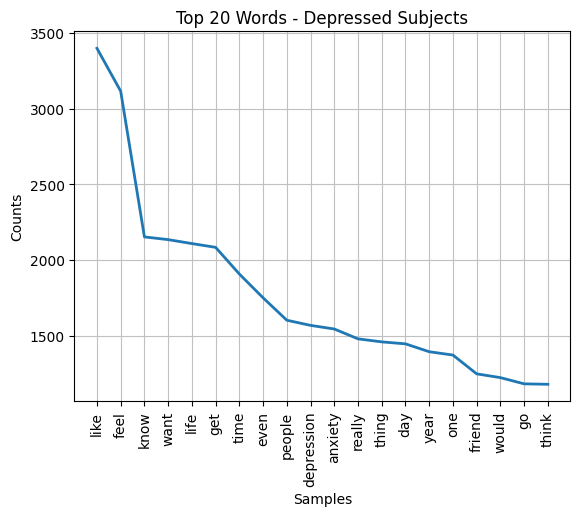

In [ ]:
# Step 9: Visualization - Bar Charts

# Depressed group
depressed_freq.plot(20,
                    title="Top 20 Words - Depressed Subjects")



<Axes: title={'center': 'Top 20 Words - Non-Depressed Subjects'}, xlabel='Samples', ylabel='Counts'>

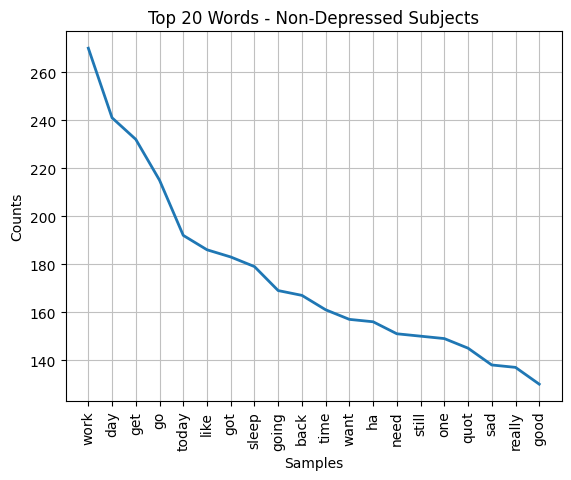

In [ ]:
# Non-depressed group
not_depressed_freq.plot(20,
                        title="Top 20 Words - Non-Depressed Subjects")

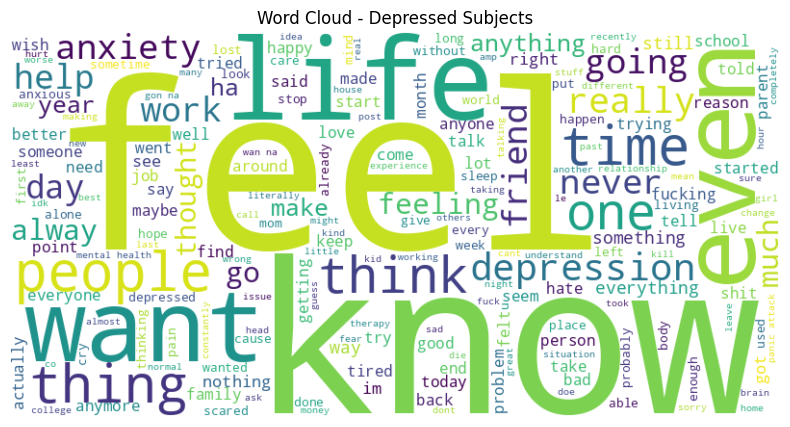

In [ ]:
# Step 10: Word Clouds

# Depressed subjects word cloud
depressed_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(depressed_tokens))

plt.figure(figsize=(10,5))
plt.imshow(depressed_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Depressed Subjects")
plt.show()



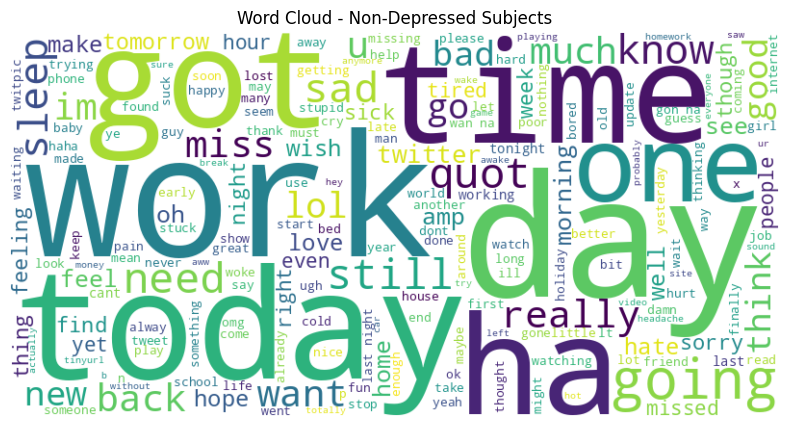

In [ ]:
# Non-depressed subjects word cloud
not_depressed_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(not_depressed_tokens))

plt.figure(figsize=(10,5))
plt.imshow(not_depressed_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Non-Depressed Subjects")
plt.show()

In [ ]:
# Step 11: Interpretation

print("\nInterpretation:")
print("Lower average sentiment indicates more negative emotional language.")
print("Frequent word analysis helps identify common themes and vocabulary.")
print("This analysis identifies linguistic patterns only and does not diagnose depression.")


Interpretation:
Lower average sentiment indicates more negative emotional language.
Frequent word analysis helps identify common themes and vocabulary.
This analysis identifies linguistic patterns only and does not diagnose depression.


In [ ]:

df[df['clean_text'].str.contains(r'\bwa\b', case=False, na=False)][['clean_text']].head(10)

,clean_text
3,i ve kind of stuffed around a lot in my life d...
7,i m not looking for sympathy just simply to st...
12,i tried to help his family abandoned him so it...
14,my father committed suicide day before my th b...
16,tw suicide yea so my recent symptom of depress...
18,i m sitting on my bed alone in my dark room sm...
20,i ve been in a bad spot for a long time i ve d...
25,i have been suffering from what i can only ima...
28,so a a kid i moved around a lot because my dad...
29,i m going 9 this year life ha always been a ro...
